In [1]:
!pip install tensorflow

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import joblib
import os
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
BASE_DIR = "/content/Predictive_Modeling"
FIG_DIR = os.path.join(BASE_DIR, "figures")
os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
print("Folders created successfully.")

Folders created successfully.


In [4]:
from google.colab import files
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print(f"Dataset Shape: {df.shape}")
print(f"Total Records: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")
print("\n--- First 5 Rows ---")
print(df.head())
print("\n--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Churn Distribution ---")
print(df["Churn"].value_counts())

Saving Dataset_ATS_v2 (2).csv to Dataset_ATS_v2 (2).csv
Dataset Shape: (7043, 10)
Total Records: 7043
Total Features: 10

--- First 5 Rows ---
   gender  SeniorCitizen Dependents  tenure PhoneService MultipleLines  \
0  Female              0         No       1           No            No   
1    Male              0         No      41          Yes            No   
2  Female              0        Yes      52          Yes            No   
3  Female              0         No       1          Yes            No   
4    Male              0         No      67          Yes            No   

  InternetService        Contract  MonthlyCharges Churn  
0             DSL  Month-to-month              25   Yes  
1             DSL        One year              25    No  
2             DSL  Month-to-month              19    No  
3             DSL        One year              76   Yes  
4     Fiber optic  Month-to-month              51    No  

--- Missing Values ---
gender             0
SeniorCitizen      

In [5]:
print("=" * 60)
print("DATA PREPROCESSING")
print("=" * 60)

# Encode Churn
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# One-hot encode
df_encoded = pd.get_dummies(df, drop_first=True)
print(f"Encoded dataset shape: {df_encoded.shape}")
print(f"Columns: {list(df_encoded.columns)}")

# Features and target
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]
print(f"\nFeatures: {X.shape}")
print(f"Target: {y.shape}")

DATA PREPROCESSING
Encoded dataset shape: (7043, 11)
Columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'Churn', 'gender_Male', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'Contract_One year', 'Contract_Two year']

Features: (7043, 10)
Target: (7043,)


In [6]:
print("=" * 60)
print("TRAIN/TEST SPLIT AND SCALING")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set: {X_train.shape[0]} records")
print(f"Testing set:  {X_test.shape[0]} records")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

joblib.dump(scaler, os.path.join(BASE_DIR, "ann_scaler.pkl"))
print("Scaler saved. Scaling completed.")

TRAIN/TEST SPLIT AND SCALING
Training set: 5634 records
Testing set:  1409 records
Scaler saved. Scaling completed.


In [7]:
print("=" * 60)
print("BUILDING ANN MODEL")
print("=" * 60)

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

BUILDING ANN MODEL


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
print("=" * 60)
print("TRAINING THE ANN MODEL")
print("=" * 60)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)
print("Training completed.")

TRAINING THE ANN MODEL
Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7229 - loss: 0.5404 - val_accuracy: 0.7906 - val_loss: 0.4598
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7644 - loss: 0.4850 - val_accuracy: 0.8021 - val_loss: 0.4403
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7675 - loss: 0.4698 - val_accuracy: 0.8030 - val_loss: 0.4368
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7757 - loss: 0.4650 - val_accuracy: 0.8021 - val_loss: 0.4362
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7788 - loss: 0.4576 - val_accuracy: 0.7915 - val_loss: 0.4363
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7710 - loss: 0.4632 - val_accuracy: 0.8004 - val_loss: 0.4361
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7837 - loss: 0.4565 - val_accuracy: 0.8030 - val_loss: 0.4352
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7766 - loss: 0.

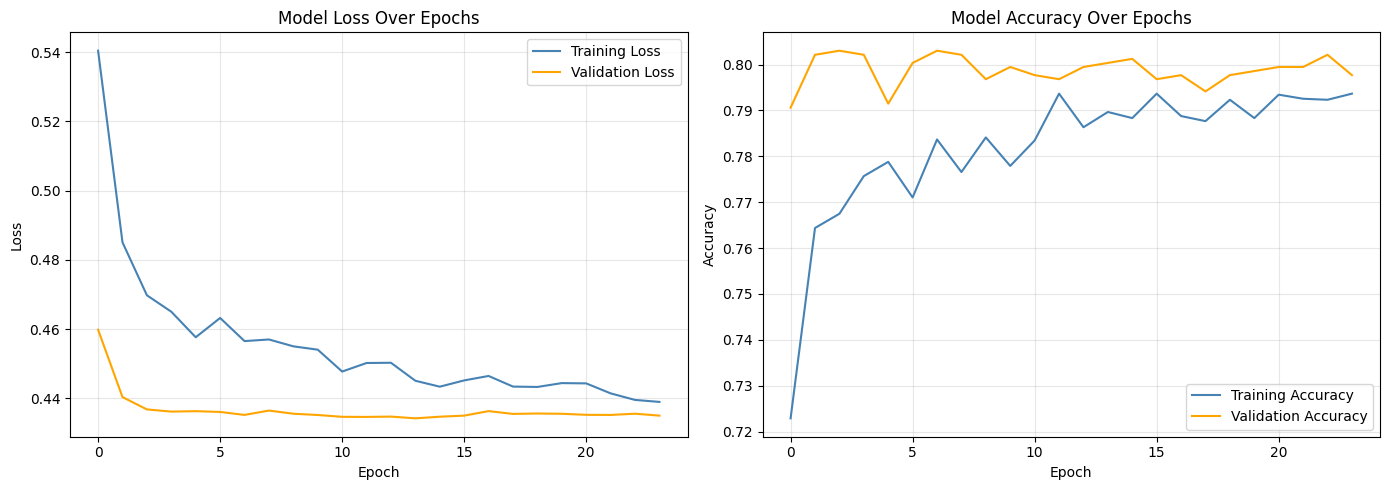

Training history saved.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Training Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='orange')
axes[0].set_title('Model Loss Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Training Accuracy', color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[1].set_title('Model Accuracy Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "training_history.png"), dpi=200)
plt.show()
print("Training history saved.")

In [10]:
print("=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

accuracy = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_pred_prob)

print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=["Not Churned", "Churned"]))

MODEL EVALUATION
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Accuracy  : 78.78%
ROC-AUC   : 0.8066

Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.83      0.90      0.86      1035
     Churned       0.63      0.47      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



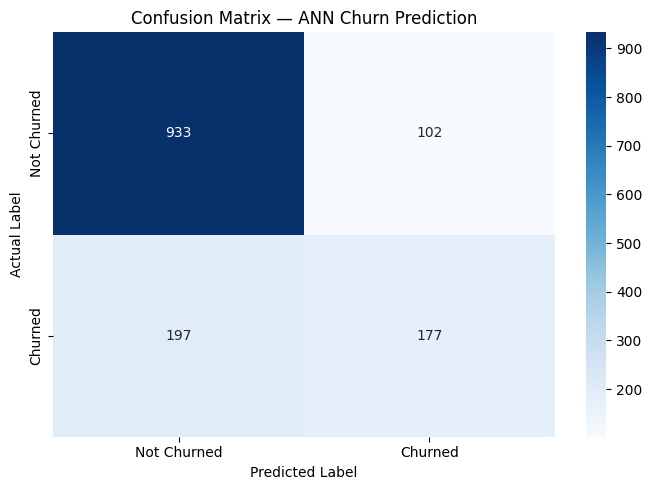

True Negatives  : 933
False Positives : 102
False Negatives : 197
True Positives  : 177


In [11]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Not Churned", "Churned"],
            yticklabels=["Not Churned", "Churned"])
plt.title("Confusion Matrix — ANN Churn Prediction")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "confusion_matrix.png"), dpi=200)
plt.show()

print(f"True Negatives  : {tn}")
print(f"False Positives : {fp}")
print(f"False Negatives : {fn}")
print(f"True Positives  : {tp}")

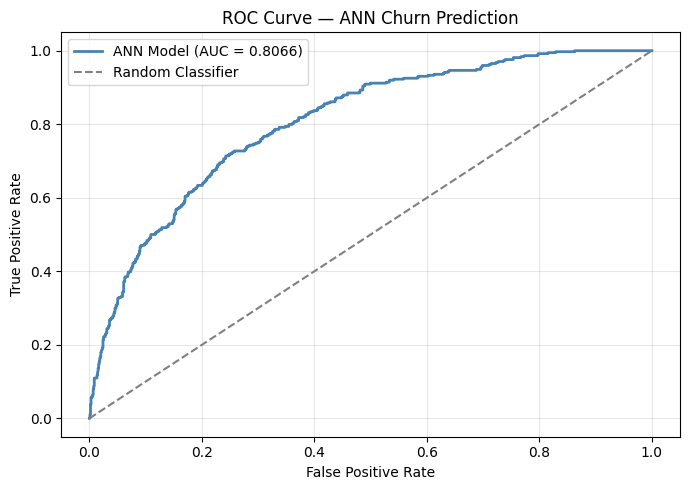

ROC curve saved.


In [12]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2,
         label=f'ANN Model (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--',
         label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — ANN Churn Prediction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "roc_curve.png"), dpi=200)
plt.show()
print("ROC curve saved.")

Feature Importance Ranking:
                    Feature  Importance
                     tenure    0.228165
             MonthlyCharges    0.173501
           PhoneService_Yes    0.149902
          Contract_Two year    0.135567
              SeniorCitizen    0.127022
          Contract_One year    0.125582
          MultipleLines_Yes    0.125579
                gender_Male    0.123866
             Dependents_Yes    0.123154
InternetService_Fiber optic    0.116398


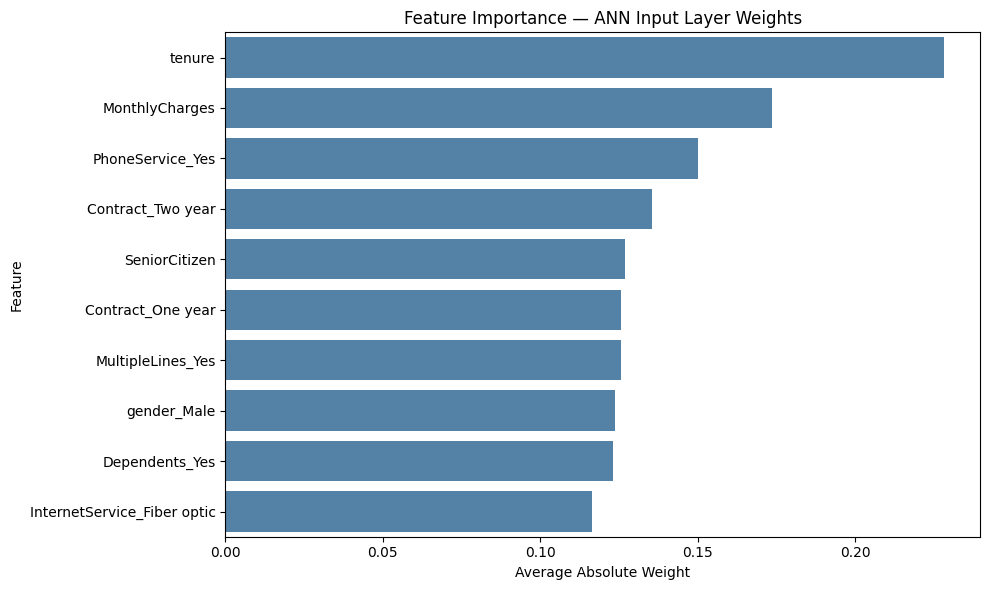

In [13]:
weights = np.abs(model.layers[0].get_weights()[0])
feature_importance = weights.mean(axis=1)
feature_names = X.columns.tolist()

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("Feature Importance Ranking:")
print(feat_df.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df, x='Importance', y='Feature', color='steelblue')
plt.title('Feature Importance — ANN Input Layer Weights')
plt.xlabel('Average Absolute Weight')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "feature_importance.png"), dpi=200)
plt.show()

In [14]:
print("=" * 60)
print("CONNECTION TO STAGE 2 CLUSTERING RESULTS")
print("=" * 60)

cluster_churn = {
    0: {"label": "Standard Non-Senior Customers",   "churn_rate": 23.2},
    1: {"label": "At-Risk Mid-Tenure Customers",     "churn_rate": 25.7},
    2: {"label": "Budget-Conscious Customers",       "churn_rate": 24.9},
    3: {"label": "Loyal Long-Tenure Customers",      "churn_rate": 21.5},
    4: {"label": "High-Risk Senior Customers",       "churn_rate": 41.6},
}

print("\nCluster | Label                          | Churn Rate | Risk Level")
print("-" * 75)
for k, v in cluster_churn.items():
    risk = "HIGH RISK" if v["churn_rate"] > 30 else "MODERATE" if v["churn_rate"] > 23 else "LOW"
    print(f"   {k}    | {v['label']:<35} | {v['churn_rate']}%      | {risk}")

CONNECTION TO STAGE 2 CLUSTERING RESULTS

Cluster | Label                          | Churn Rate | Risk Level
---------------------------------------------------------------------------
   0    | Standard Non-Senior Customers       | 23.2%      | MODERATE
   1    | At-Risk Mid-Tenure Customers        | 25.7%      | MODERATE
   2    | Budget-Conscious Customers          | 24.9%      | MODERATE
   3    | Loyal Long-Tenure Customers         | 21.5%      | LOW
   4    | High-Risk Senior Customers          | 41.6%      | HIGH RISK


In [15]:
model.save(os.path.join(BASE_DIR, "ann_churn_model.h5"))
print("Model saved as ann_churn_model.h5")

summary = f"""
ANN Model Evaluation Summary
==============================
Dataset        : Dataset_ATS_v2.csv
Total Records  : {df.shape[0]}
Training Set   : {X_train_scaled.shape[0]} records (80%)
Testing Set    : {X_test_scaled.shape[0]} records (20%)

Architecture:
  Input Layer   : {X_train_scaled.shape[1]} neurons
  Hidden Layer 1: 64 neurons, ReLU, Dropout 0.3
  Hidden Layer 2: 32 neurons, ReLU, Dropout 0.2
  Output Layer  : 1 neuron, Sigmoid

Training Config:
  Optimizer     : Adam
  Loss Function : Binary Crossentropy
  Epochs        : 50 (Early Stopping patience=10)
  Batch Size    : 32

Performance:
  Accuracy      : {accuracy*100:.2f}%
  ROC-AUC Score : {roc_auc:.4f}

Confusion Matrix:
  True Negatives : {tn}
  False Positives: {fp}
  False Negatives: {fn}
  True Positives : {tp}
"""

with open(os.path.join(BASE_DIR, "model_evaluation_summary.txt"), "w") as f:
    f.write(summary)

print(summary)

Model saved as ann_churn_model.h5

ANN Model Evaluation Summary
Dataset        : Dataset_ATS_v2.csv
Total Records  : 7043
Training Set   : 5634 records (80%)
Testing Set    : 1409 records (20%)

Architecture:
  Input Layer   : 10 neurons
  Hidden Layer 1: 64 neurons, ReLU, Dropout 0.3
  Hidden Layer 2: 32 neurons, ReLU, Dropout 0.2
  Output Layer  : 1 neuron, Sigmoid

Training Config:
  Optimizer     : Adam
  Loss Function : Binary Crossentropy
  Epochs        : 50 (Early Stopping patience=10)
  Batch Size    : 32

Performance:
  Accuracy      : 78.78%
  ROC-AUC Score : 0.8066

Confusion Matrix:
  True Negatives : 933
  False Positives: 102
  False Negatives: 197
  True Positives : 177



In [16]:
import shutil
from google.colab import files

shutil.make_archive("/content/Predictive_Modeling", "zip", "/content/Predictive_Modeling")
files.download("/content/Predictive_Modeling.zip")
print("All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded!
